In [20]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pyrtools as pt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Steerable pyramids

The steerable pyramid transform given below is described in:
E P Simoncelli and W T Freeman.  
The Steerable Pyramid: A Flexible Architecture for Multi-Scale 
Derivative Computation.  
IEEE Second Int'l Conf on Image Processing.  
Washington DC,  October 1995.  
Online access:  
http://www.cns.nyu.edu/pub/eero/simoncelli95b.pdf


The steerable pyramid is a multi-scale representation that is
**translation-invariant**, but that also includes representation of
**orientation**.  Furthermore, the representation of orientation is
designed to be rotation-invariant. The basis/projection functions
are oriented (steerable) filters, localized in space and frequency.
**It is overcomplete to avoid aliasing**.  And it is "self-inverting"
(like the QMF/Wavelet transform): the projection functions and 
basis functions are identical.  The mathematical phrase for a 
transform obeying this property is "tight frame".

The system diagram for the steerable pyramid (described in the
reference given below) is as follows:<pre>
 IM ---> fhi0 -----------------> H0 ---------------- fhi0 ---> RESULT
     |                                                     |
     |                                                     |
     |-> flo0 ---> fl1/down2 --> L1 --> up2/fl1 ---> flo0 -|
               |                                 |
               |----> fb0 -----> B0 ----> fb0 ---|
               |                                 |
               |----> fb1 -----> B1 ----> fb1 ---|
               .                                 .
               .                                 .
               |----> fbK -----> BK ----> fbK ---|
</pre>
The filters {fhi0,flo0} are used to initially split the image into
a highpass residual band H0 and a lowpass subband.  This lowpass
band is then split into a low(er)pass band L1 and K+1 oriented
subbands {B0,B1,...,BK}.  The representatation is substantially
overcomplete.  The pyramid is built by recursively splitting the
lowpass band (L1) using the inner portion of the diagram (i.e.,
using the filters {fl1,fb0,fb1,...,fbK}).  The resulting transform is
overcomplete by a factor of 4k/3.

The scale tuning of the filters is constrained by the recursive
system diagram.  The orientation tuning is constrained by requiring
the property of steerability.  A set of filters form a steerable
basis if they 1) are rotated copies of each other, and 2) a copy of
the filter at any orientation may be computed as a linear
combination of the basis filters.  The simplest examples of
steerable filters is a set of N+1 Nth-order directional
derivatives.

## Spatial Domain construction
### Choose a filter set
options are: 'sp0_filters', 'sp1_filters', 'sp3_filters', 'sp5_filters'


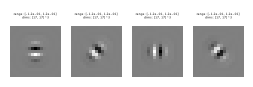

In [21]:
filters = pt.steerable_filters('sp3_filters')

fsz = int(np.round(np.sqrt(filters['bfilts'].shape[0])))
fsz = np.array([fsz, fsz])
nfilts = filters['bfilts'].shape[1]
nrows = int(np.floor(np.sqrt(nfilts)))

import scipy.signal as sps
# Look at the oriented bandpass filters:
filtList = []
for f in range(nfilts):
    filtList.append(sps.convolve2d(filters['bfilts'][:,f].reshape(fsz), filters['lo0filt']))

pt.imshow(filtList, vrange='auto', zoom=3);

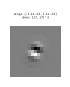

In [22]:
# Try "steering" to a new orientation (new_ori in degrees):
new_ori = 22
# new_ori = 360*np.random.rand(1)[0]

pt.imshow( sps.convolve2d( pt.pyramids.steer(filters['bfilts'],
                                      new_ori * np.pi/180).reshape(fsz),
                           filters['lo0filt']), 'auto', zoom=3);

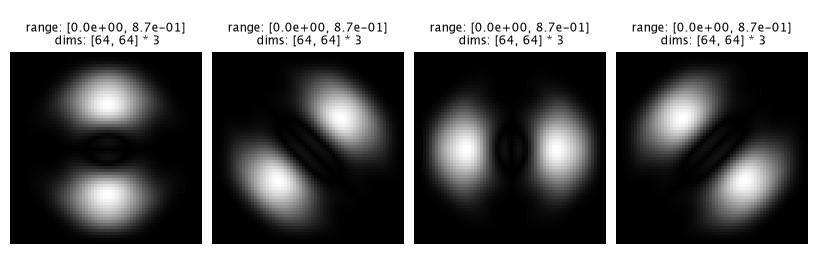

In [23]:
# Look at Fourier transform magnitudes:
lo0filt = filters['lo0filt']
bfilts = filters['bfilts']
lo0 = np.fft.fftshift(np.abs(np.fft.fft2(filters['lo0filt'], (64,64)))) # zero padding
fsum = np.zeros(lo0.shape)
imgList = []
for f in range(bfilts.shape[1]):
    flt = bfilts[:,f].reshape(fsz)
    freq = lo0 * np.fft.fftshift(np.abs(np.fft.fft2(flt, (64,64))))
    fsum += freq**2
    imgList.append(freq)

pt.imshow(imgList, 'auto', zoom=3, col_wrap= 4);

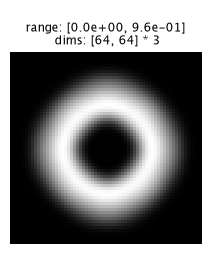

In [24]:
# The filters sum to a smooth annular ring:
pt.imshow(fsum, 'auto', 3);

### Visualizing steerable pyramid coefficients of an image

In [39]:
im = plt.imread('../DATA/Curie.pgm').astype(float)
# im = pt.blurDn(im, 1, 'qmf9')
# pt.imshow(im);

filt = 'sp3_filters' # There are 4 orientations for this filter
pyr = pt.pyramids.SteerablePyramidSpace(im, height=4, order=3)

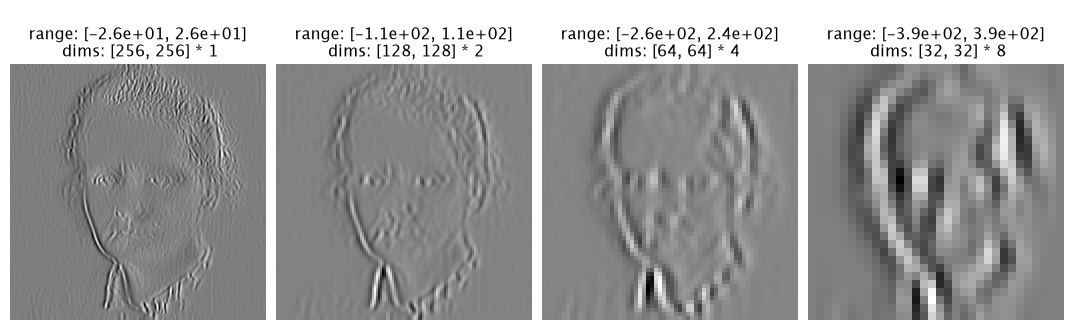

In [40]:
# Look at first (vertical) bands, different scales:
imgList = []
for s in range(pyr.num_scales):
    band = pyr.pyr_coeffs[(s,0)]
    imgList.append(band)
pt.imshow(imgList, col_wrap=4);

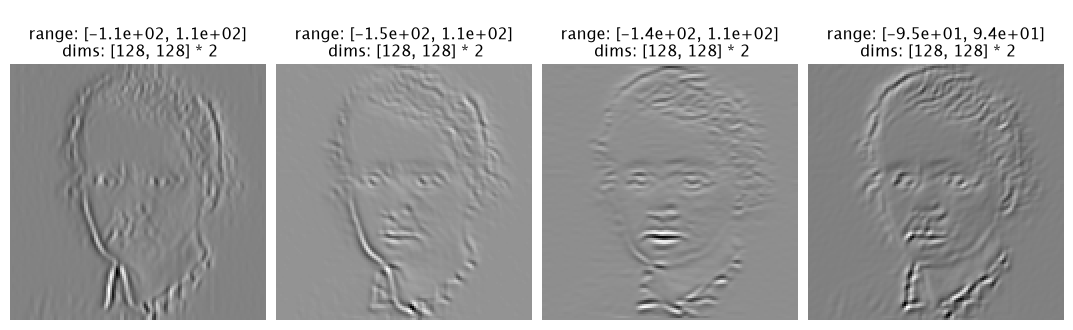

In [41]:
# look at all orientation bands at one level (scale):
imgList = []
for b in range(pyr.num_orientations):
    band = pyr.pyr_coeffs[(1,b)]
    imgList.append(band)

pt.imshow(imgList, zoom=2, col_wrap=4);

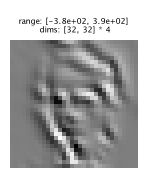

In [42]:
# look at one level and band (ie. scale and orientation):
pt.imshow(pyr.pyr_coeffs[(3,1)], 'auto', zoom=4);

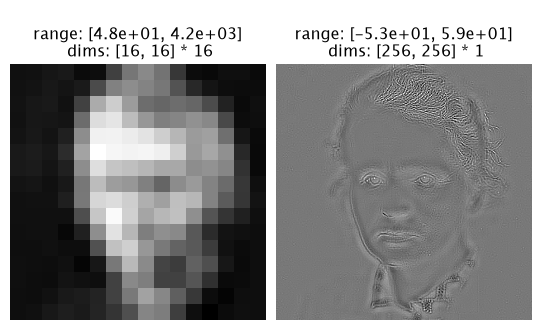

In [43]:
# To access the high-pass and low-pass bands:
low = pyr.pyr_coeffs['residual_lowpass']
high = pyr.pyr_coeffs['residual_highpass']
pt.imshow([low, high]);

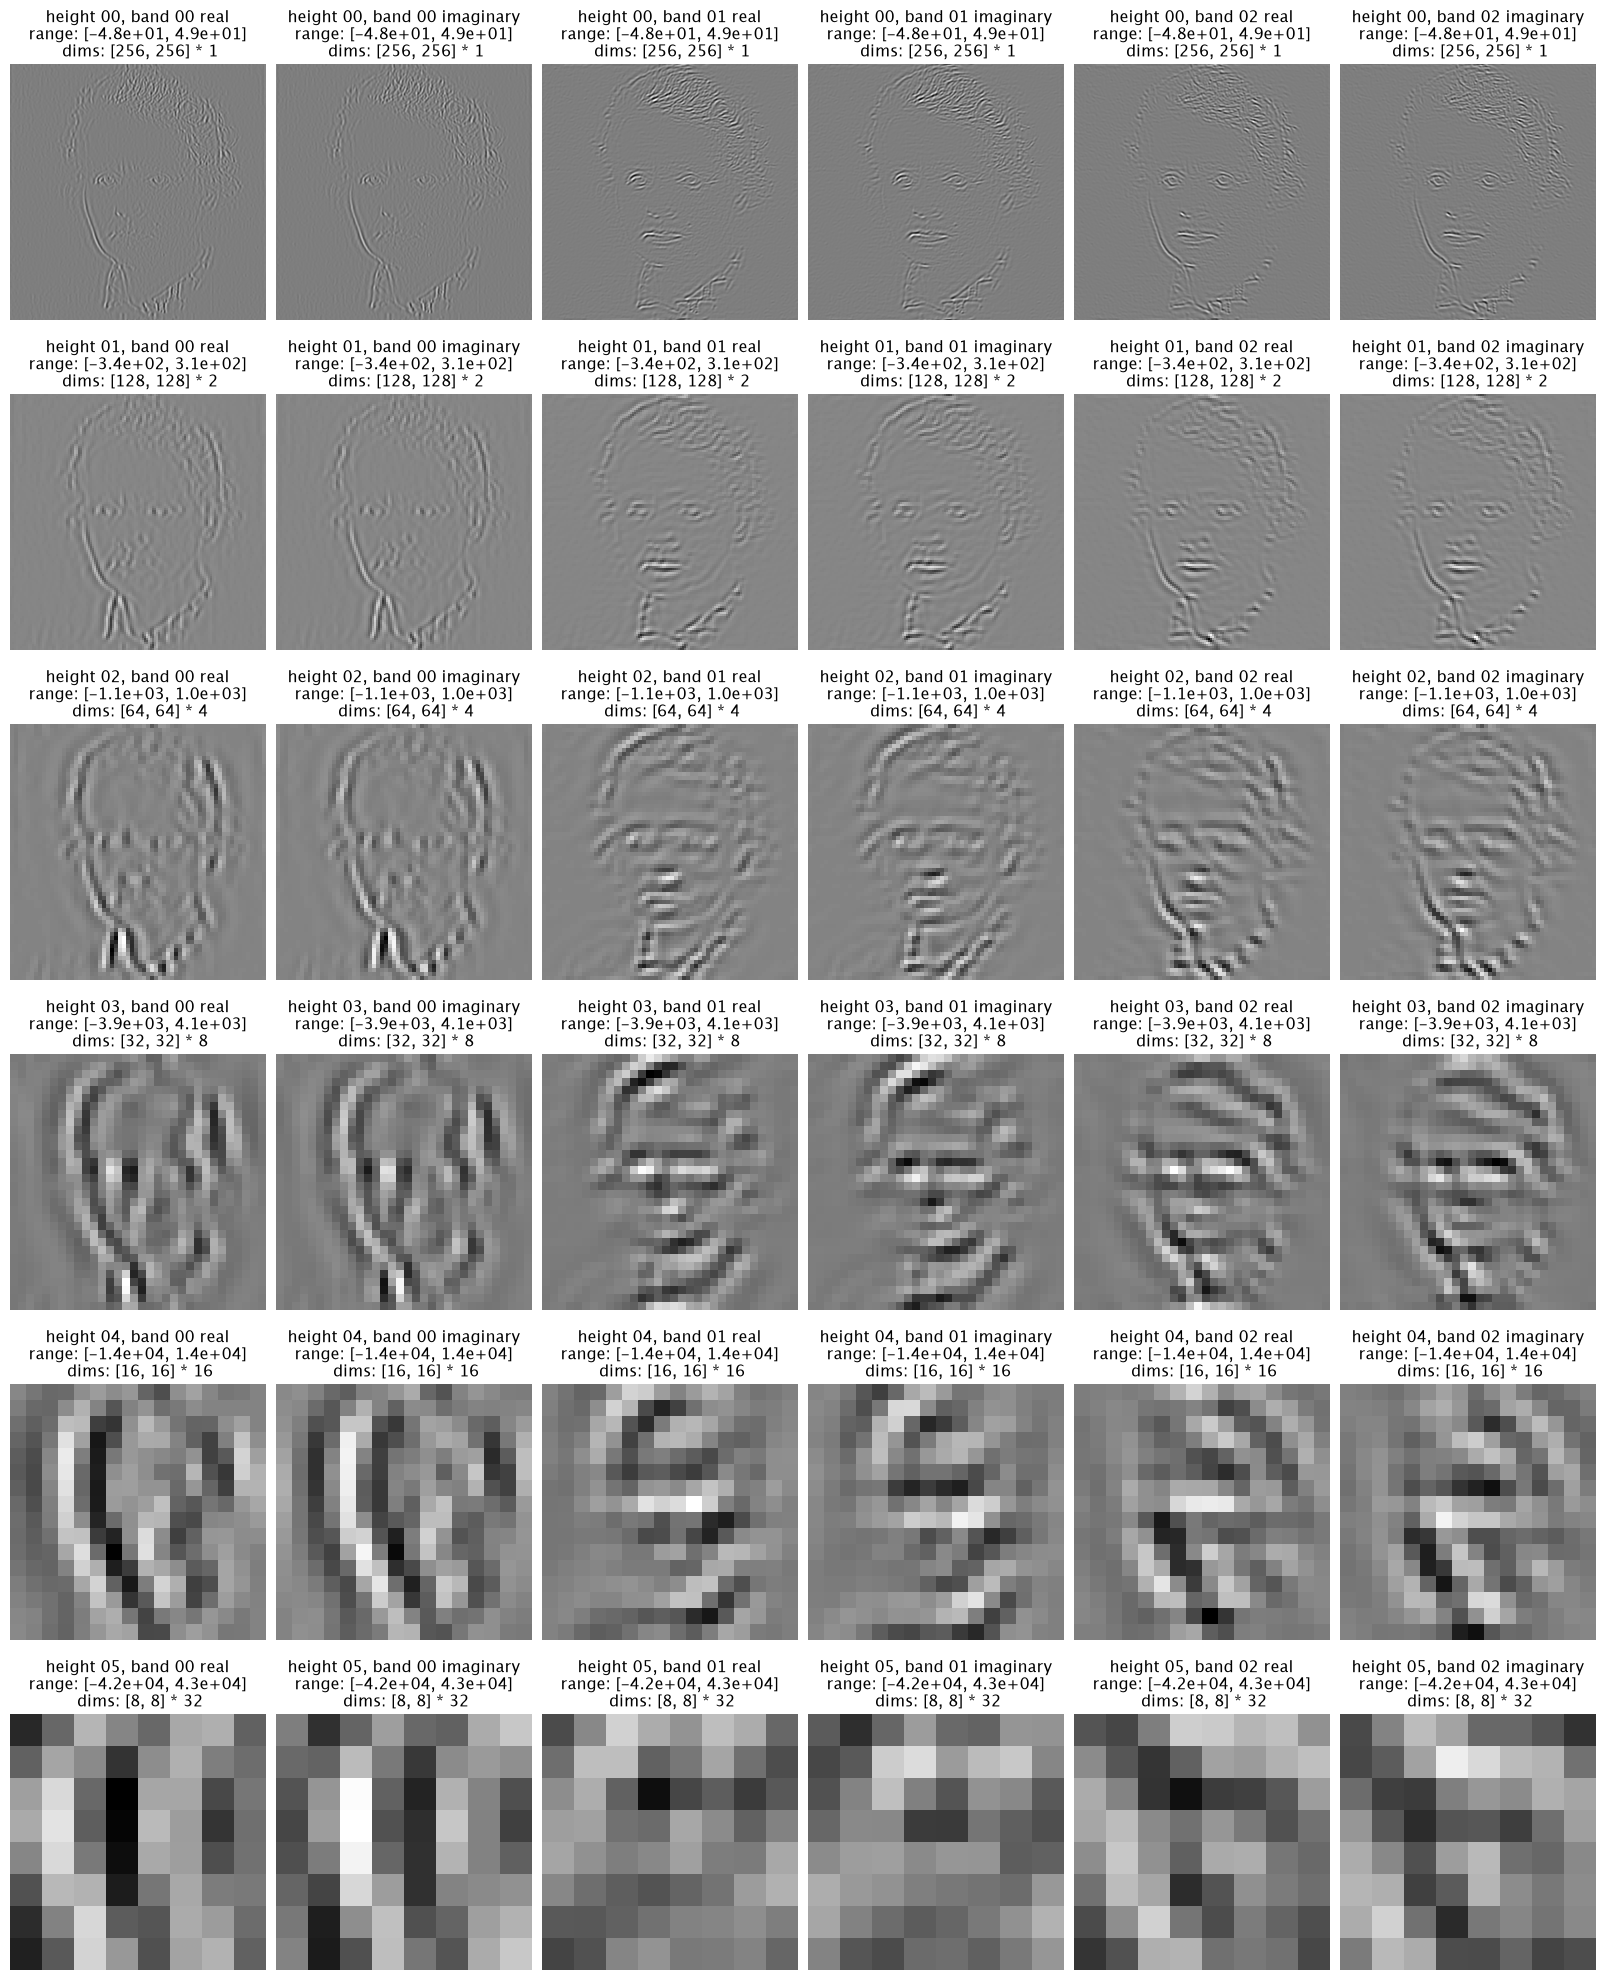

In [67]:
# Display the whole pyramid 
# Not showing residuals because vrange defaults to Auto1row which computes
# the min and max across the low pass and high pass residuals and these
# values will be very different between the low pass and high pass. 
# Note that images are shown at same size for ease of visulization:


pt.pyrshow(pyr.pyr_coeffs, show_residuals = False);

### Steering
Spin a level of the pyramid, interpolating (steering to) intermediate orienations

In [45]:
s = 2 # pick a scale
lev = np.array([pyr.pyr_coeffs[(s, i)] for i in range(pyr.num_orientations)]) 
n = lev[0].shape[0] * lev[0].shape[1]
# create a matrix containing outputs of the pyramid in long columns
lev2 = np.concatenate((lev[0].reshape((n,1)),
                       lev[1].reshape((n,1)),
                       lev[2].reshape((n,1)),
                       lev[3].reshape((n,1))),
                      axis=1)
# print(lev.shape, lev2.shape)

filters = pt.steerable_filters(filt)

k = 32
M = np.empty((k, lev.shape[1], lev.shape[2]))

for frame in range(k):
    steered_im = pt.pyramids.steer(lev2, 2 * np.pi*frame/k,
                                   filters['harmonics'],
                                   filters['mtx']).reshape(lev.shape[-2:])
    M[frame] = steered_im

In [46]:
# NOTE: to show the animation properly, make sure ffmpeg is installed. For anaconda users do:
# conda install -c conda-forge ffmpeg

pt.animshow(M, framerate=6, zoom=4, repeat=True)

### Reconstruction
Note that the filters are not perfect, although they are good enough for most applications.

Difference statistics:
  Range: [-113, 22]
  Mean: -0.770771,  Stdev (rmse): 7.192672,  SNR (dB): 21.011911


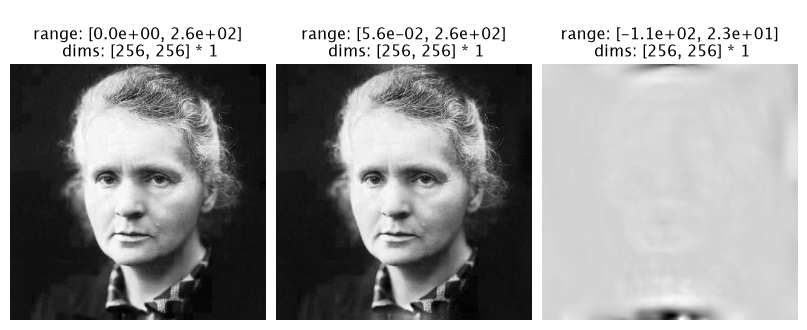

In [47]:
res = pyr.recon_pyr()
pt.imshow([im, res, im - res]); # note the different range of the error subplot
pt.image_compare(im, res);

As with previous pyramids, you can select subsets of the levels
and orientation bands to be included in the reconstruction.  For example:

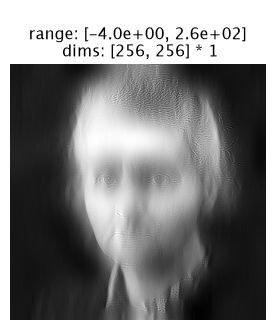

In [48]:
# All levels (including highpass and lowpass residuals), one orientation:
pt.imshow(pyr.recon_pyr(levels='all', bands=[0]));

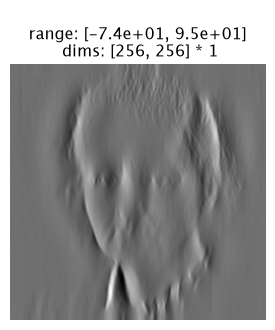

In [49]:
# Without the highpass and lowpass:
pt.imshow(pyr.recon_pyr(levels=range(pyr.num_scales), bands=[0]));

## Frequency domain construction

We also provide an implementation of the Steerable pyramid in the
Frequency domain.  The advantages are perfect-reconstruction
(within floating-point error), and any number of orientation
bands.  The disadvantages are that it is typically slower, and the
boundary handling is always circular.

### Impulse response

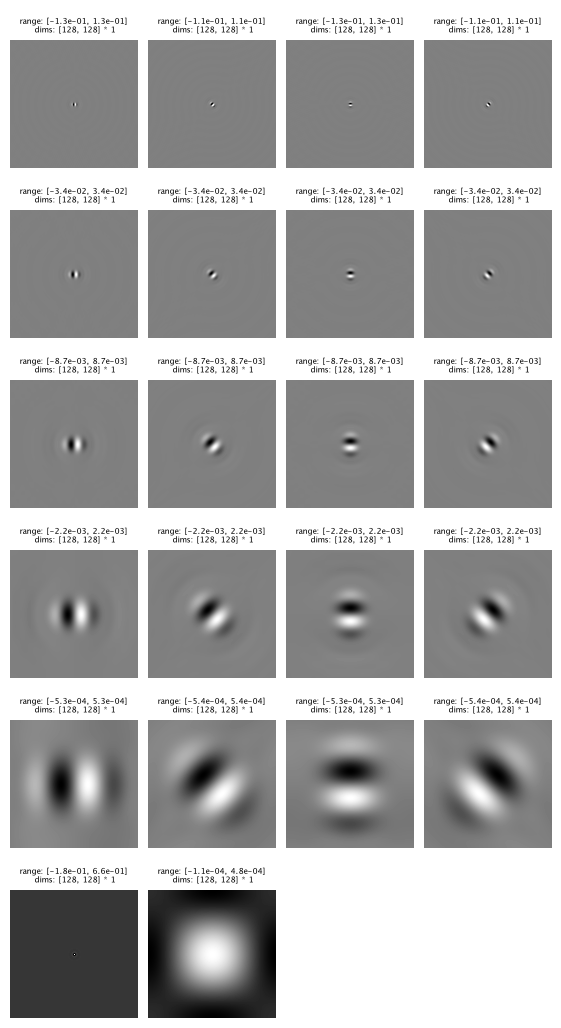

In [50]:
sz = 128
empty_image = np.zeros((sz,sz))
pyr = pt.pyramids.SteerablePyramidFreq(empty_image, height='auto', order=3)

### Put an  impulse into the middle of each band:
for k, v in pyr.pyr_size.items():
    mid = (v[0]//2, v[1]//2)
#     print(lev, mid)
    pyr.pyr_coeffs[k][mid] = 1
# pt.pyrshow(pyr.pyr_coeffs, vrange='indep1');

# And take a look at the reconstruction of each band:
reconList = []
for k in pyr.pyr_coeffs.keys():
    if isinstance(k, tuple):
        reconList.append(pyr.recon_pyr(k[0], k[1]))
for k in ['residual_highpass', 'residual_lowpass']:
    reconList.append(pyr.recon_pyr(k))

pt.imshow(reconList, col_wrap=pyr.num_orientations, vrange='indep1');

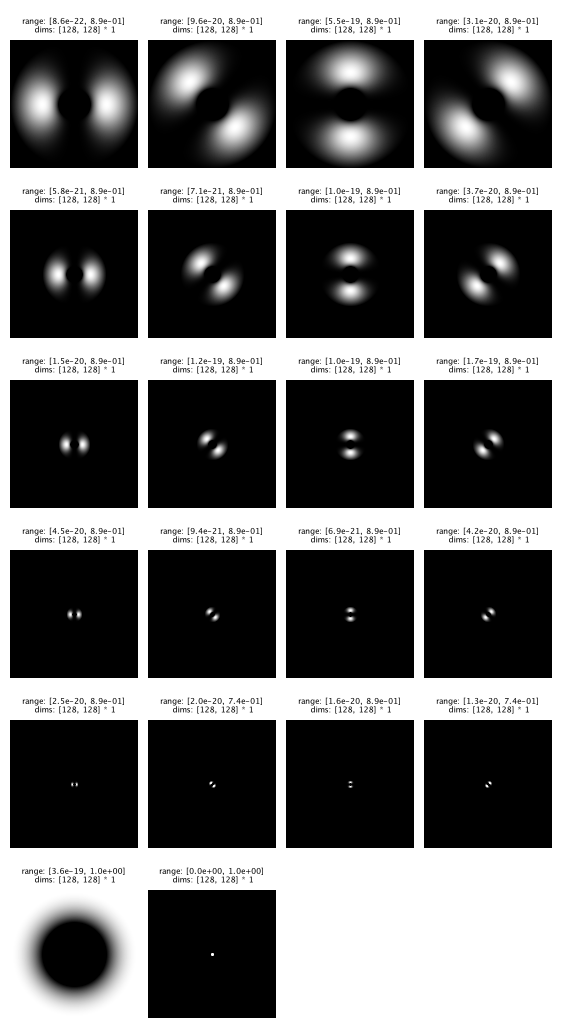

In [51]:
# now in the frequency domain
freq = 2 * np.pi * np.array(range(-sz//2,(sz//2)))/sz
imgList = []
for k in pyr.pyr_coeffs.keys():
    if isinstance(k, tuple):
        basisFn = pyr.recon_pyr(k[0], k[1])
        basisFmag = np.fft.fftshift(np.abs(np.fft.fft2(basisFn, (sz,sz))))
        imgList.append(basisFmag)

for k in ['residual_highpass', 'residual_lowpass']:
    basisFn = pyr.recon_pyr(k)
    basisFmag = np.fft.fftshift(np.abs(np.fft.fft2(basisFn, (sz,sz))))
    imgList.append(basisFmag)

pt.imshow(imgList, col_wrap=pyr.num_orientations);

### Visualization and reconstruction

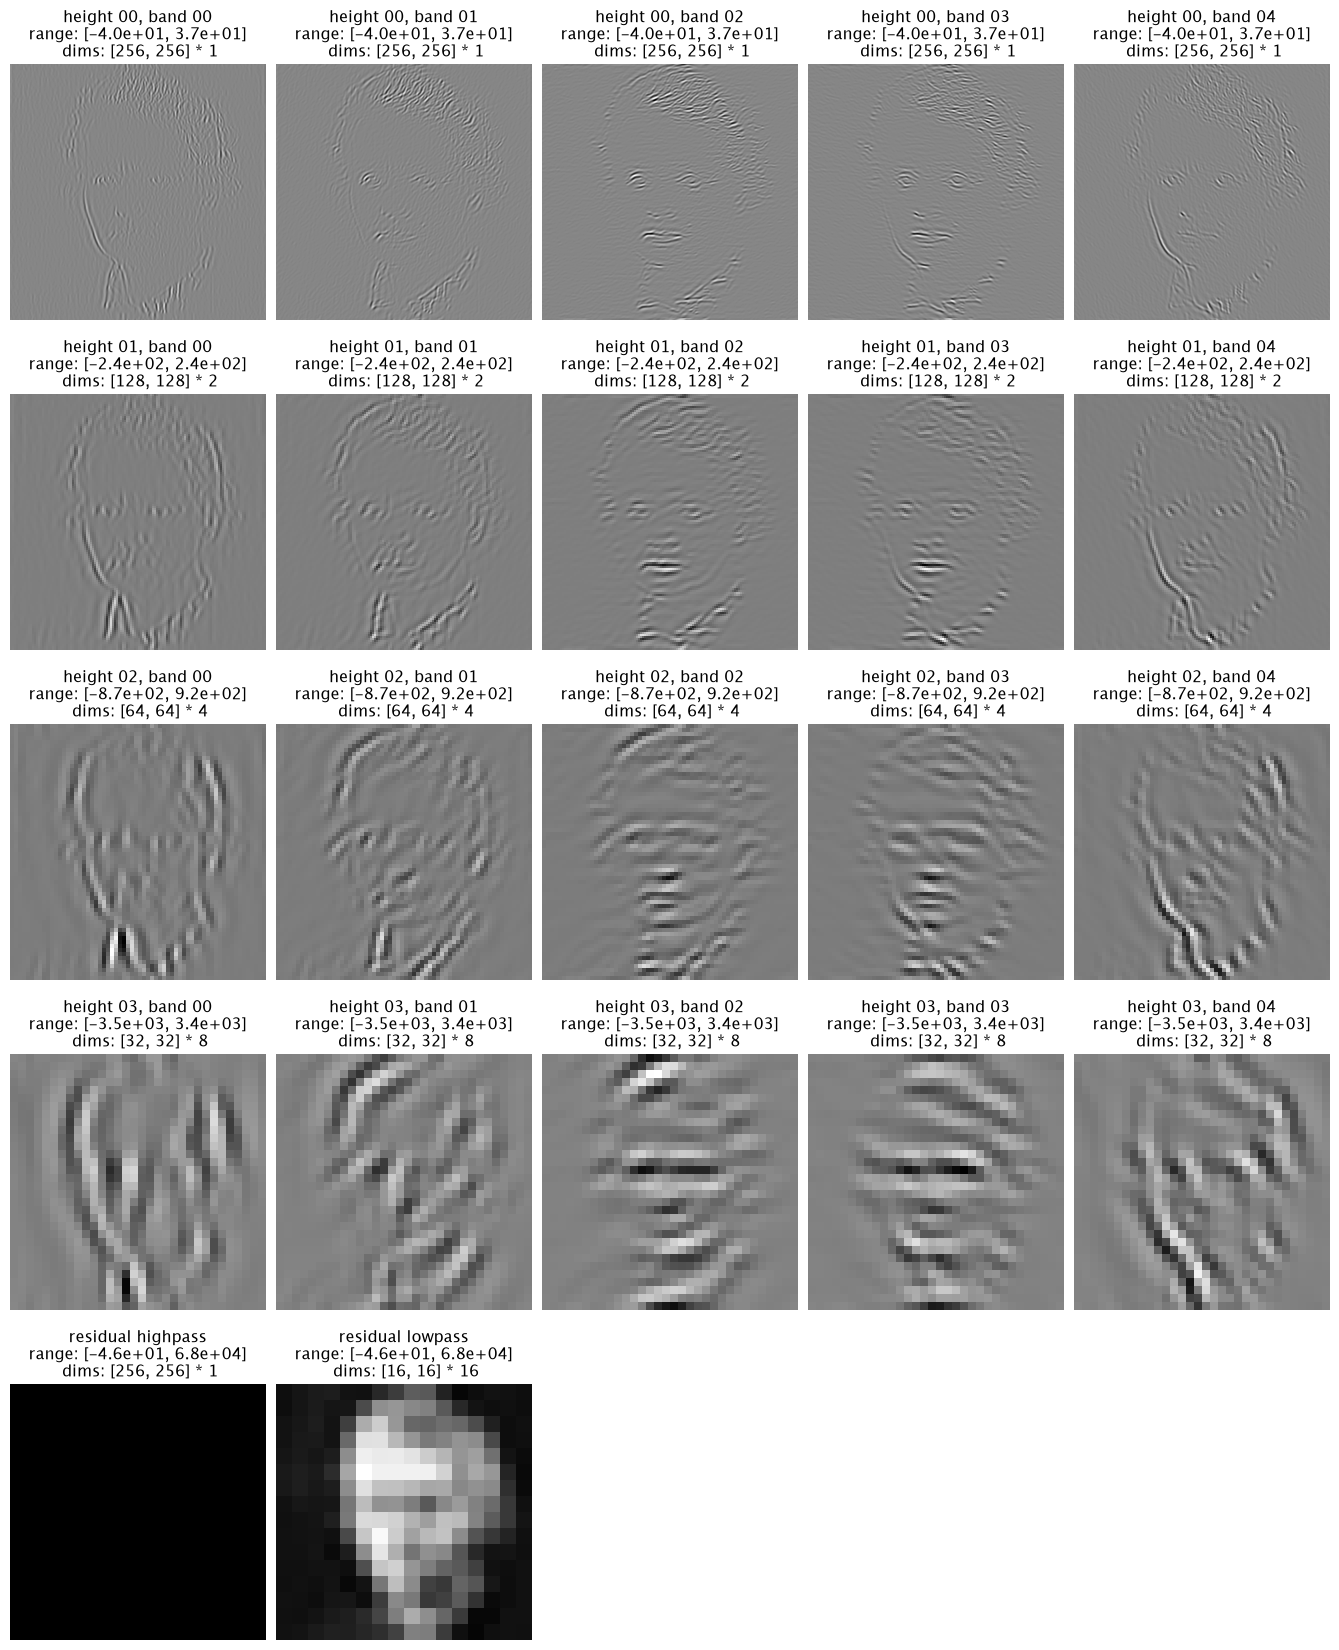

In [52]:
# 4 levels, 5 orientation bands
pyr = pt.pyramids.SteerablePyramidFreq(im, height=4, order=4)
pt.pyrshow(pyr.pyr_coeffs);

Difference statistics:
  Range: [0, 0]
  Mean: 0.000000,  Stdev (rmse): 0.000334,  SNR (dB): 107.682181


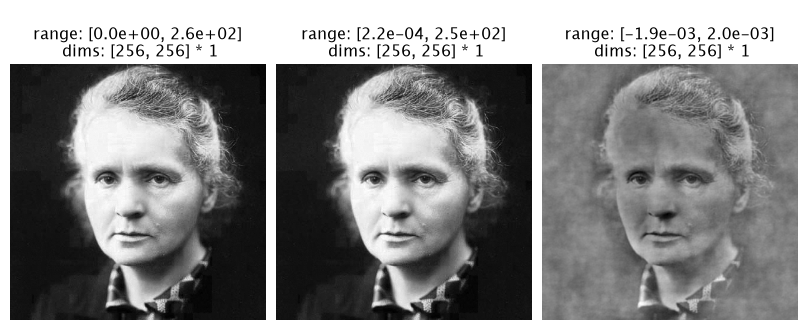

In [53]:
res = pyr.recon_pyr()
pt.image_compare(im,res);  # nearly perfect

pt.imshow([im, res, im-res]); # note the different range of the error subplot

### Steerability in the frequency domain




Just as in the spatial domain, this frequency domain construction of the pyramid can be steered to other orientations than those used when constructing the pyramid.

We use again the `steer_coeffs` method, and visualize it's effect both in the spatial and frequency domains.

In [54]:
num_orientations_steered = 120
steered_coeffs, steering_vectors = pyr.steer_coeffs([i*np.pi/180
                                            for i in np.linspace(-180, 180, num_orientations_steered)])

steered_coeffs_dft = {}
for k, v in steered_coeffs.items():
    steered_coeffs_dft[k] = np.fft.fftshift(np.abs(np.fft.fft2(v,
                                                s=pyr.pyr_coeffs[(k[0], 0)].shape)))

In [55]:
pt.animshow(np.array([steered_coeffs[(0, i)] for i in range(num_orientations_steered)]),
                   framerate=12, repeat=True)

In [56]:
pt.animshow(np.array([steered_coeffs_dft[(0, i)] for i in range(num_orientations_steered)]),
            framerate=12, repeat=True)

In [57]:
pt.animshow(np.array([steered_coeffs[(1, i)] for i in range(num_orientations_steered)]),
            framerate=12, zoom=2, repeat=True)

In [58]:
pt.animshow(np.array([steered_coeffs_dft[(1, i)] for i in range(num_orientations_steered)]),
            framerate=12, zoom=2, repeat=True)

In [59]:
# the steering weighting vectors

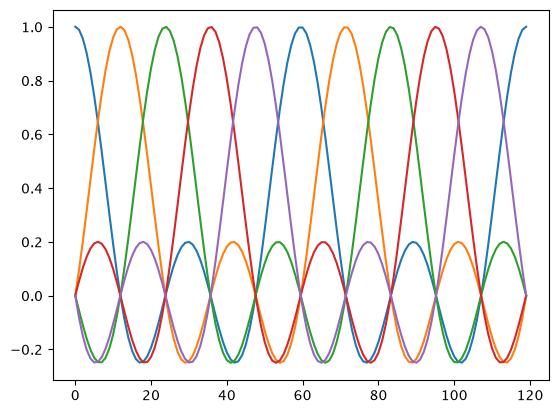

In [60]:
plt.figure()
for i in range(pyr.num_orientations):
    plt.plot(np.vstack([steering_vectors[(0, j)] for j in range(num_orientations_steered)])[:, i])
plt.show()

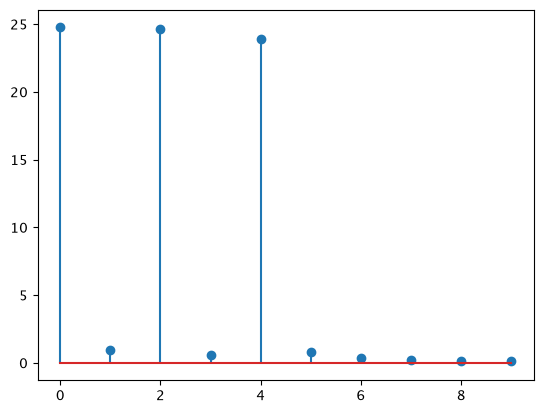

In [61]:
# expected harmonics (up to sapling error)
i = np.random.choice(pyr.num_orientations)
sp = np.fft.fftshift(np.fft.fft(np.vstack([steering_vectors[(1, j)] for j in range(num_orientations_steered)])[:, i]))
plt.stem(np.abs(sp)[sp.shape[0] // 2 : sp.shape[0] // 2 + pyr.num_orientations * 2]);

### Complex valued Steerable Pyramid


*as described in:  
A parametric texture model based on joint statistics of complex wavelet coefficients  
J Portilla and E P Simoncelli.  
Int'l Journal of Computer Vision, vol.40(1), pp. 49--71, Dec 2000  
http://www.cns.nyu.edu/pub/eero/portilla99-reprint.pdf*

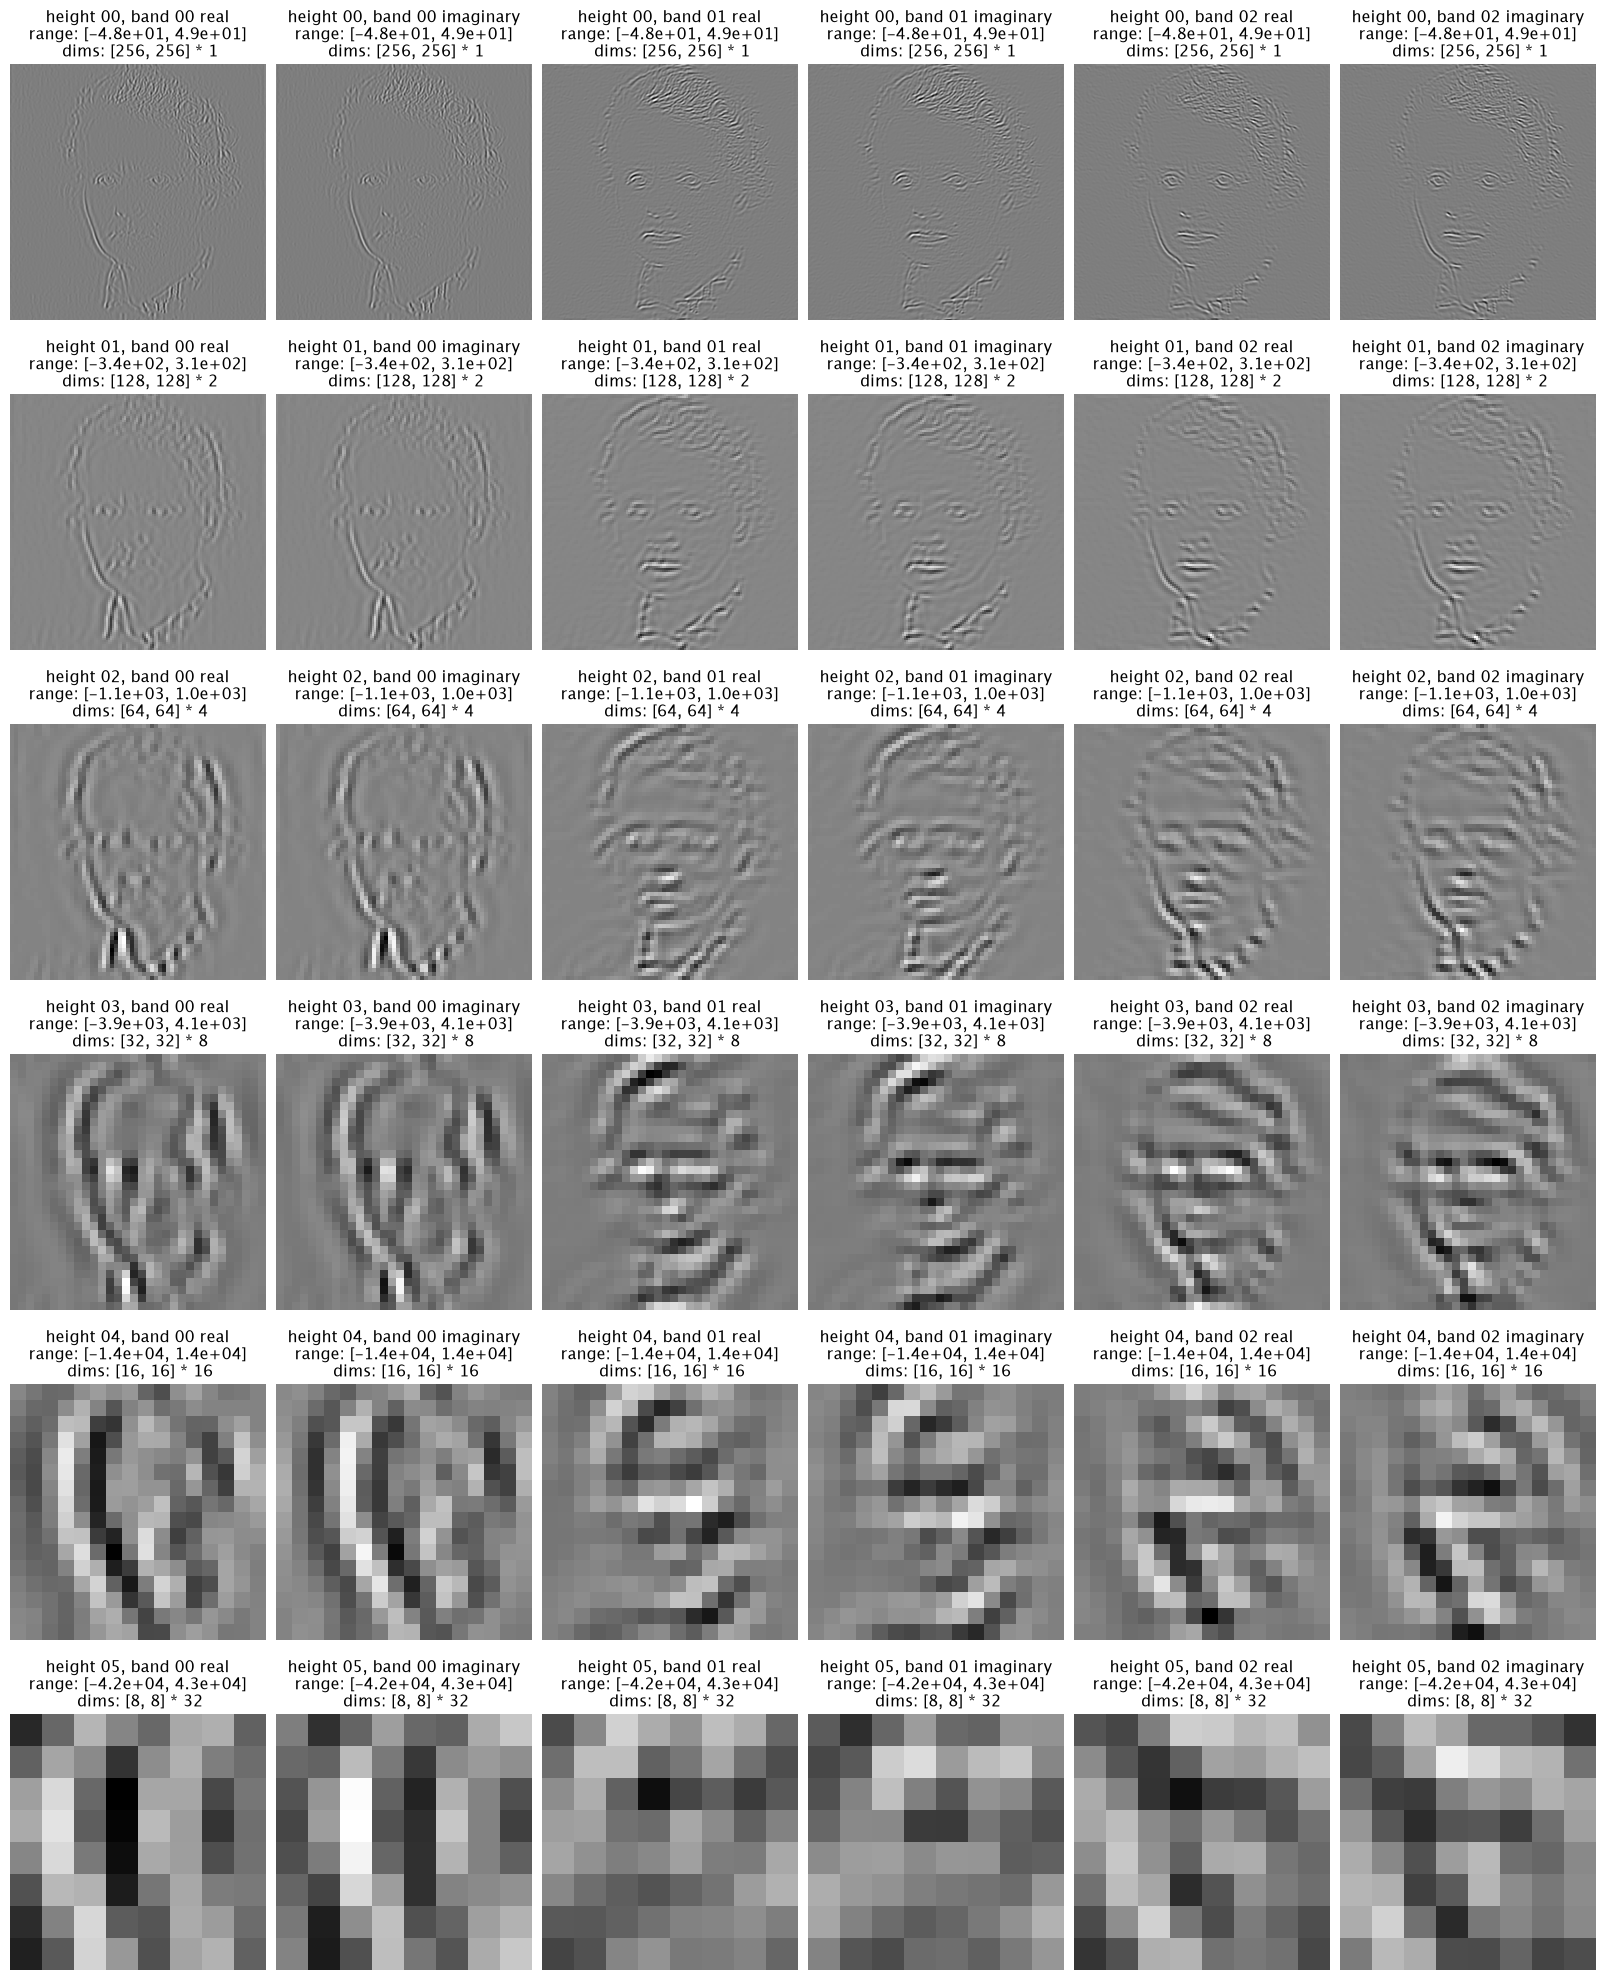

In [66]:
pyr = pt.pyramids.SteerablePyramidFreq(im, order=2, is_complex=True)
# twice as many orientations
# filters organized in quadrature pair
# note that this construction is not steerable
#note need additional argument pyr.is_complex to pyrshow because default is False
pt.pyrshow(pyr.pyr_coeffs, show_residuals = False);